## Data Preprocessing

In [81]:
import torch
import numpy
import random
import re

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [83]:
SEED = 42

random.seed(SEED)
numpy.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [84]:
with open("../data/input.txt") as file:
    text = file.read()

# text = text.lower()
text = re.sub(r'[^a-zA-Z0-9 .\n]', '', text).lower()
chars = sorted(set(text))

print(f"Length of data: {len(text)}")
print(f"Vocabulary Size: {len(chars)}")

Length of data: 1068882
Vocabulary Size: 30


In [85]:
stoi = {char:i for i,char in enumerate(chars)}
itos = {i:char for i,char in enumerate(chars)}

def encode(text):
    return [stoi[i] for i in text]

def decode(ids):
    return "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype = torch.int64)
# data = data[:int(0.2 * data.shape[0])]   # using only 20% for quick test

In [86]:
split = int(0.9 * len(data))
train = data[:split]
test = data[split:]

print(f"No. of chars in train dataset: {len(train)}")
print(f"No. of chars in test dataset: {len(test)}\n")

block_size = 32

X_train = []
y_train = []

for i in range(len(train) - block_size):
    X_train.append(train[i:i + block_size])
    y_train.append(train[i+block_size])

X_train = torch.stack(X_train)
y_train = torch.stack(y_train)
print(f"No. of datapoints in train dataset: {len(X_train)}")
print(f"X_train shape : {X_train.shape}")
print(f"y_train shape: {y_train.shape}\n")

X_test = []
y_test = []

for i in range(len(test) - block_size):
    X_test.append(test[i:i + block_size])
    y_test.append(test[i + block_size])

X_test = torch.stack(X_test)
y_test = torch.stack(y_test)
print(f"No. of datapoints in test dataset: {len(X_test)}")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

No. of chars in train dataset: 961993
No. of chars in test dataset: 106889

No. of datapoints in train dataset: 961961
X_train shape : torch.Size([961961, 32])
y_train shape: torch.Size([961961])

No. of datapoints in test dataset: 106857
X_test shape : torch.Size([106857, 32])
y_test shape: torch.Size([106857])


## MLP

In [87]:
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader


# Data Loader

batch_size = 512

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)  

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Model

vocab_size = len(chars)
embedding_dim = 64
hidden_dim1 = 256
hidden_dim2 = 128

model = nn.Sequential(
    nn.Embedding(vocab_size, embedding_dim),
    nn.Flatten(),
    nn.Linear(block_size * embedding_dim, hidden_dim1),
    nn.ReLU(),
    nn.Linear(hidden_dim1, hidden_dim2),
    nn.Linear(hidden_dim2, vocab_size)
)

model = model.to(device)

print(model)

Sequential(
  (0): Embedding(30, 64)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=2048, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): Linear(in_features=128, out_features=30, bias=True)
)


In [88]:
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Total trainable parameters: 563230


In [89]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loss_ = []
test_loss_ = []
epochs = 10

for epoch in range(epochs):

    # Training
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward
        logits = model(X_batch)

        # Loss
        loss = loss_fn(logits, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Testing
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            test_loss += loss.item()

        test_loss /= len(test_loader)

    train_loss_.append(train_loss)
    test_loss_.append(test_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f}"
    )

Epoch [1/10] Train Loss: 1.9152 | Test Loss: 1.8692
Epoch [2/10] Train Loss: 1.6550 | Test Loss: 1.8064
Epoch [3/10] Train Loss: 1.5793 | Test Loss: 1.7799
Epoch [4/10] Train Loss: 1.5371 | Test Loss: 1.7709
Epoch [5/10] Train Loss: 1.5078 | Test Loss: 1.7522
Epoch [6/10] Train Loss: 1.4848 | Test Loss: 1.7559
Epoch [7/10] Train Loss: 1.4674 | Test Loss: 1.7634
Epoch [8/10] Train Loss: 1.4523 | Test Loss: 1.7622
Epoch [9/10] Train Loss: 1.4397 | Test Loss: 1.7596
Epoch [10/10] Train Loss: 1.4288 | Test Loss: 1.7637


In [90]:
torch.save(model.state_dict(), "../models/MLP_char_predictor.pth")

In [91]:
model = nn.Sequential(
    nn.Embedding(vocab_size, embedding_dim),
    nn.Flatten(),
    nn.Linear(block_size * embedding_dim, hidden_dim1),
    nn.ReLU(),
    nn.Linear(hidden_dim1, hidden_dim2),
    nn.Linear(hidden_dim2, vocab_size)
)

model.load_state_dict(
    torch.load("../models/MLP_char_predictor.pth", map_location=device)
)

model = model.to(device)
model.eval()

print("Model loaded!")

Model loaded!


In [92]:
def generate(model, text, max_new_chars):

    if(len(text) < 32):
        print("Alert! Minimum 32 char input is required.")
        return

    model.eval()

    for _ in range(max_new_chars):

        # Encode input
        context = torch.tensor(
            encode(text[-block_size:]),
            dtype=torch.long,
            device=device
        ).unsqueeze(0) # unsqueeze(0) - add a dim 1, model was trained to receive a batch of sequences, 
                      # so even when generating only one sequence, you need to represent it as a batch of size 1.

        with torch.no_grad():
            logits = model(context)

        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1).item()
        next_char = decode([next_id])

        text += next_char

    return text

In [93]:
input = "with a lovely evening and a cool wind"

output = generate(model, input, 400)
print(output)

with a lovely evening and a cool winds
friend strembelliant being thought
let he noscapker trened judgmy livalle
threyers me tyranness pray thou hes
she snall alrnoo behing am that timp

king him
and that come queen worn oursell
as no forth coarl of mormend to i so confins
i charmious then heme mouthds noth a little

condempst the houghtss the reason.
the greaterful min make me contunted by

sheps isshen bandshmess yet by this
batter


In [94]:
output = generate(model, input, 400)
print(output)

with a lovely evening and a cool wind with le
suil plupretchey my halvel but jois withort.

rerenio
hor prisone knatted the dospiry
istever it corfinf.

encelo

marcusio
my shall our own the crapter dew
hhy peraugh but your soat the hair day.

utricia
hes have a handichs wilt will i haps 
pight thin prighter even murh sinstnioe
and this love i on my boy
what i am recood that would relain
i purgen but a king emmornot all
have cons i t


## Visualization

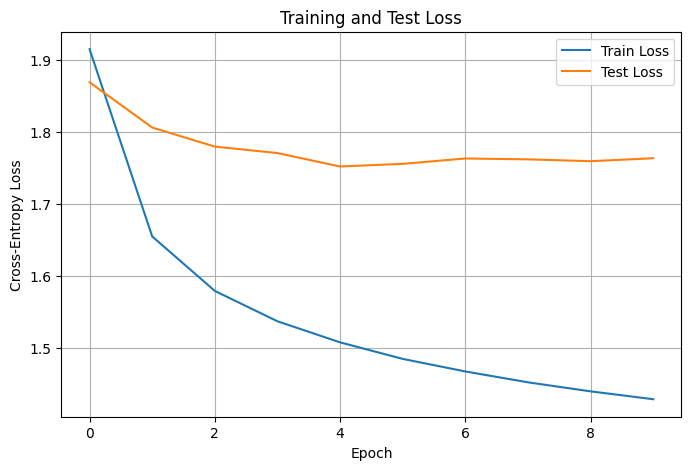

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_loss_, label="Train Loss")
plt.plot(test_loss_, label="Test Loss")

plt.title("Training and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")

plt.legend()
plt.grid(True)

plt.show()

In [96]:
import plotly.express as px
from sklearn.decomposition import PCA

# Get learned embeddings
embeddings = model[0].weight.detach().cpu().numpy()

# PCA → 2 dimensions
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Create dataframe
import pandas as pd

df = pd.DataFrame({
    "PC1": embeddings_2d[:, 0],
    "PC2": embeddings_2d[:, 1],
    "char": [repr(c) for c in chars]
})

# Interactive plot
fig = px.scatter(
    df,
    x="PC1",
    y="PC2",
    text="char",
    title="Character Embeddings — PCA"
)

fig.update_traces(
    textposition="top center",
    marker=dict(size=10)
)

fig.update_layout(
    xaxis_title="PC1",
    yaxis_title="PC2"
)

fig.show()